In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/insurance.csv")
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
target = "charges"

In [4]:
X = df.drop(columns=[target])
X

,age,gender,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [5]:
y = df[target]
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [7]:
X.region.unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [8]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
dtypes: float64(1), int64(2), str(3)
memory usage: 84.0 KB


In [10]:
X = pd.get_dummies(X, drop_first=True)
X

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [11]:
from sklearn import model_selection

In [12]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)

In [13]:
len(X_train)/len(X)

0.6995515695067265

In [14]:
X_train

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
479,23,32.560,0,True,False,False,True,False
868,61,23.655,0,True,False,False,False,False
804,23,26.510,0,True,False,False,True,False
677,60,31.350,3,True,True,True,False,False
160,42,26.600,0,False,True,True,False,False
...,...,...,...,...,...,...,...,...
899,19,22.515,0,False,False,True,False,False
16,52,30.780,1,False,False,False,False,False
133,19,25.555,0,True,False,True,False,False
1337,61,29.070,0,False,True,True,False,False


In [15]:
# Standar Scaling, Z transformation
# Z score = (x-x_mean)/x_std, x feature

In [16]:
from sklearn import preprocessing

In [17]:
scaler = preprocessing.StandardScaler()

In [18]:
X_train_std = scaler.fit_transform(X_train)
X_train_std

array([[-1.1655525 ,  0.30708473, -0.89446416, ..., -0.55595945,
         1.59966727, -0.55595945],
       [ 1.55182895, -1.13402454, -0.89446416, ..., -0.55595945,
        -0.62513   , -0.55595945],
       [-1.1655525 , -0.67199568, -0.89446416, ..., -0.55595945,
         1.59966727, -0.55595945],
       ...,
       [-1.45159265, -0.82654474, -0.89446416, ...,  1.79869234,
        -0.62513   , -0.55595945],
       [ 1.55182895, -0.25770711, -0.89446416, ...,  1.79869234,
        -0.62513   , -0.55595945],
       [ 0.97974864,  0.26500855,  0.72648154, ..., -0.55595945,
        -0.62513   , -0.55595945]], shape=(936, 8))

In [20]:
pd.DataFrame(X_train_std, columns=X_train.columns)

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.165553,0.307085,-0.894464,0.974679,-0.521286,-0.555959,1.599667,-0.555959
1,1.551829,-1.134025,-0.894464,0.974679,-0.521286,-0.555959,-0.625130,-0.555959
2,-1.165553,-0.671996,-0.894464,0.974679,-0.521286,-0.555959,1.599667,-0.555959
3,1.480319,0.111269,1.536954,0.974679,1.918333,1.798692,-0.625130,-0.555959
4,0.193138,-0.657431,-0.894464,-1.025978,1.918333,1.798692,-0.625130,-0.555959
...,...,...,...,...,...,...,...,...
931,-1.451593,-1.318512,-0.894464,-1.025978,-0.521286,1.798692,-0.625130,-0.555959
932,0.908239,0.019025,-0.083991,-1.025978,-0.521286,-0.555959,-0.625130,-0.555959
933,-1.451593,-0.826545,-0.894464,0.974679,-0.521286,1.798692,-0.625130,-0.555959
934,1.551829,-0.257707,-0.894464,-1.025978,1.918333,1.798692,-0.625130,-0.555959


In [21]:
pd.DataFrame(X_train_std, columns=X_train.columns).describe()

,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02,9.360000e+02
mean,-1.632123e-16,-2.543075e-16,-7.211705e-17,1.195625e-16,-3.036507e-17,-3.226289e-17,-2.467162e-17,-4.175198e-17
std,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00,1.000535e+00
min,-1.523103e+00,-2.379318e+00,-8.944642e-01,-1.025978e+00,-5.212860e-01,-5.559594e-01,-6.251300e-01,-5.559594e-01
25%,-8.795123e-01,-7.343008e-01,-8.944642e-01,-1.025978e+00,-5.212860e-01,-5.559594e-01,-6.251300e-01,-5.559594e-01
50%,-2.139189e-02,-1.172327e-02,-8.399131e-02,9.746794e-01,-5.212860e-01,-5.559594e-01,-6.251300e-01,-5.559594e-01
75%,8.367286e-01,6.722170e-01,7.264815e-01,9.746794e-01,-5.212860e-01,-5.559594e-01,1.599667e+00,-5.559594e-01
max,1.766359e+00,3.546951e+00,3.157900e+00,9.746794e-01,1.918333e+00,1.798692e+00,1.599667e+00,1.798692e+00


In [22]:
scaler.mean_

array([39.2991453 , 30.66244124,  1.10363248,  0.51282051,  0.21367521,
        0.23611111,  0.28098291,  0.23611111])

In [24]:
scaler.var_

array([1.95553674e+02, 3.81833496e+01, 1.52237997e+00, 2.49835634e-01,
       1.68018117e-01, 1.80362654e-01, 2.02031513e-01, 1.80362654e-01])

In [25]:
X_test_std = scaler.transform(X_test)
X_test_std

array([[-1.23706254,  0.66958723,  1.53695439, ..., -0.55595945,
        -0.62513   ,  1.79869234],
       [ 1.76635906, -0.81926232,  0.72648154, ..., -0.55595945,
        -0.62513   ,  1.79869234],
       [-0.80800231, -1.11055898,  0.72648154, ..., -0.55595945,
        -0.62513   ,  1.79869234],
       ...,
       [-0.16441197,  2.74103009,  0.72648154, ..., -0.55595945,
        -0.62513   ,  1.79869234],
       [ 0.26464826, -0.6412477 ,  0.72648154, ..., -0.55595945,
        -0.62513   ,  1.79869234],
       [ 0.12162818,  0.15739062, -0.08399131, ..., -0.55595945,
        -0.62513   , -0.55595945]], shape=(402, 8))

In [26]:
from sklearn import linear_model

In [27]:
est = linear_model.LinearRegression()
est.fit(X_train_std, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3567.39,2126.28, 635.94,...,-283.36,-466.94,-370.97]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.336e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[38.06,35.26,32.37,...,29.08,26.63,17.23]"


In [28]:
y_train_pred = est.predict(X_train_std)
y_test_pred = est.predict(X_test_std)

In [32]:
a = pd.DataFrame({'y': y_test, 'y_pred': y_test_pred})
a['error'] = a.y - a.y_pred
a

,y,y_pred,error
880,3443.06400,6106.534023,-2663.470023
398,14988.43200,13139.802626,1848.629374
555,3847.67400,3336.670147,511.003853
859,10965.44600,11183.501364,-218.055364
973,1759.33800,5715.330847,-3955.992847
...,...,...,...
801,14313.84630,15470.918078,-1157.071778
320,4894.75330,5064.014796,-169.261496
860,46113.51100,37386.734731,8726.776269
1171,22478.60000,31725.705991,-9247.105991


<Axes: xlabel='y', ylabel='y_pred'>

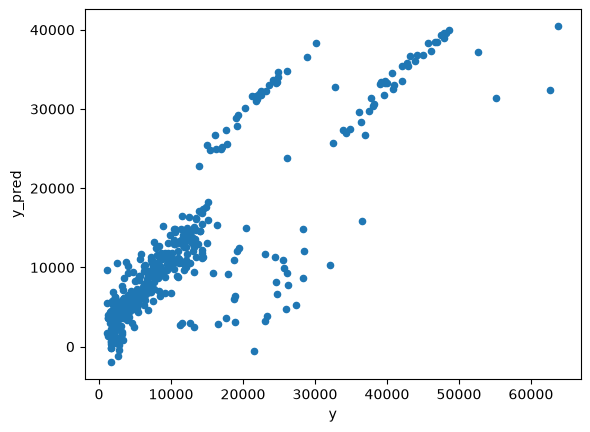

In [31]:
a.plot.scatter("y", "y_pred")

In [36]:
import matplotlib.pyplot as plt

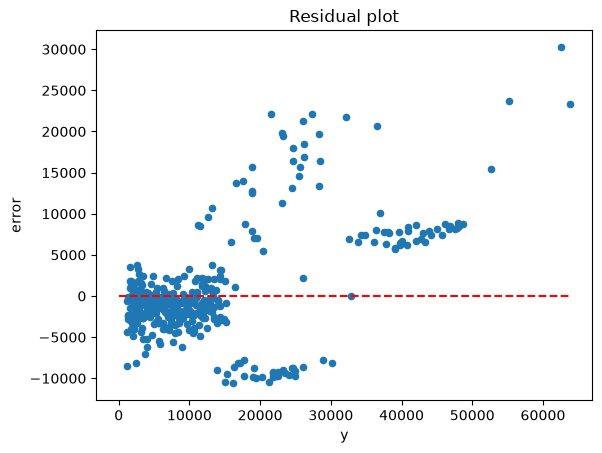

In [38]:
a.plot.scatter("y", "error")
plt.title("Residual plot")
plt.hlines(0, 0, y_test.max(), ls = "--", color = "red")

<Axes: ylabel='Frequency'>

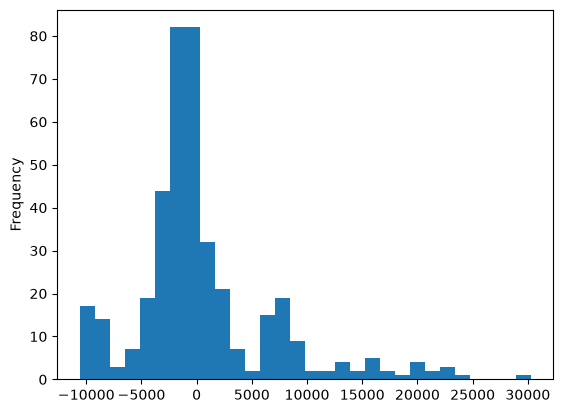

In [35]:
a.error.plot.hist(bins = 30)

In [39]:
est.intercept_

np.float64(13360.26692698611)

In [40]:
est.coef_

array([3567.39175031, 2126.27557579,  635.93542757,   20.50594935,
       9675.94315931, -283.35662852, -466.94170732, -370.97154147])

Estimation of the output var: 

y_hat = 13360.26692698611 + 3567.39175031 age + 2126.27557579 bmi + ....

In [41]:
X_train.columns

Index(['age', 'bmi', 'children', 'gender_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')

In [42]:
a

,y,y_pred,error
880,3443.06400,6106.534023,-2663.470023
398,14988.43200,13139.802626,1848.629374
555,3847.67400,3336.670147,511.003853
859,10965.44600,11183.501364,-218.055364
973,1759.33800,5715.330847,-3955.992847
...,...,...,...
801,14313.84630,15470.918078,-1157.071778
320,4894.75330,5064.014796,-169.261496
860,46113.51100,37386.734731,8726.776269
1171,22478.60000,31725.705991,-9247.105991


In [43]:
import numpy as np

In [45]:
mae_train = np.abs(y_train - y_train_pred).mean()
mae_test = np.abs(y_test - y_test_pred).mean()
mae_train, mae_test

(np.float64(4148.642106893159), np.float64(4187.003014471771))

In [46]:
mse_train = ((y_train - y_train_pred) ** 2).mean()
mse_test = ((y_test - y_test_pred)**2).mean()
mse_train, mse_test

(np.float64(34914887.60091363), np.float64(40412760.84529751))

In [48]:
rmse_train = np.sqrt(((y_train - y_train_pred) ** 2).mean())
rmse_test = np.sqrt(((y_test - y_test_pred)**2).mean())
rmse_train, rmse_test

(np.float64(5908.882094010138), np.float64(6357.103180324943))

In [49]:
# baseline prediction
y_train.mean() # training_baseline 
y_test.mean() # test_baseline 

np.float64(13061.23170920398)

In [52]:
sst_train = ((y_train - y_train.mean()) ** 2).sum()
sst_test = ((y_test - y_test.mean())**2).sum()
sst_train, sst_test

(np.float64(134841666018.91202), np.float64(61207408301.38713))

In [50]:
sse_train = ((y_train - y_train_pred) ** 2).sum()
sse_test = ((y_test - y_test_pred)**2).sum()
sse_train, sse_test

(np.float64(32680334794.455154), np.float64(16245929859.809597))

In [55]:
r2_train = 1 - sse_train/sst_train
r2_test = 1 - sse_test/sst_test
r2_train, r2_test

(np.float64(0.7576391944766419), np.float64(0.7345757595254785))

In [61]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)

scaler = preprocessing.StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
est = linear_model.LinearRegression()
est.fit(X_train_std, y_train)
y_train_pred = est.predict(X_train_std)
y_test_pred = est.predict(X_test_std)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

training rmse 6149.615857408637
test rmse 5811.424155380472
training r2 0.7343698539390324
test r2 0.783632366375771


In [62]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)

scaler = preprocessing.StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
est = linear_model.LinearRegression()
est.fit(X_train_std, y_train)
y_train_pred = est.predict(X_train_std)
y_test_pred = est.predict(X_test_std)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

training rmse 5942.900463270774
test rmse 6286.796494524804
training r2 0.7591121001736723
test r2 0.7299123249322759


In [68]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)

poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

scaler = preprocessing.StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
est = linear_model.LinearRegression()
est.fit(X_train_std, y_train)
y_train_pred = est.predict(X_train_std)
y_test_pred = est.predict(X_test_std)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

training rmse 4547.228689215038
test rmse 5101.04824676456
training r2 0.8588697326076197
test r2 0.8223935131394542


In [65]:
a = np.random.randint(-5, 5, (4, 3))
a

array([[ 3, -4,  1],
       [-2, -4, -4],
       [-3, -4,  2],
       [ 2,  2, -1]])

In [67]:
preprocessing.PolynomialFeatures(degree=2, include_bias=False).fit_transform(a)

array([[  3.,  -4.,   1.,   9., -12.,   3.,  16.,  -4.,   1.],
       [ -2.,  -4.,  -4.,   4.,   8.,   8.,  16.,  16.,  16.],
       [ -3.,  -4.,   2.,   9.,  12.,  -6.,  16.,  -8.,   4.],
       [  2.,   2.,  -1.,   4.,   4.,  -2.,   4.,  -2.,   1.]])

In [71]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)


pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.LinearRegression())
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

training rmse 4732.89397275592
test rmse 4655.5942884914675
training r2 0.8474788518362026
test r2 0.8512204952034504


In [72]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)


pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.LinearRegression())
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

training rmse 3987.544985609686
test rmse 5480.472715551839
training r2 0.8912012864974341
test r2 0.7962857149059399


In [73]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)


pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.LinearRegression())
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

training rmse 3497.6882464105333
test rmse 10448.146718974502
training r2 0.9099668058928005
test r2 0.35799628482898493


In [74]:
pipe.steps

[('poly', PolynomialFeatures(degree=4, include_bias=False)),
 ('scaler', StandardScaler()),
 ('est', LinearRegression())]

In [75]:
pipe.steps[-1]

('est', LinearRegression())

In [76]:
est = pipe.steps[-1][-1]
est

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](714,)","[126812.78, -312.76, 10148.86,..., 15329.05, 15329.05, 48061.45]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.286e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,714
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(317)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](714,)","[297.08,250.33,240.93,..., 0. , 0. , 0. ]"


<Axes: ylabel='Frequency'>

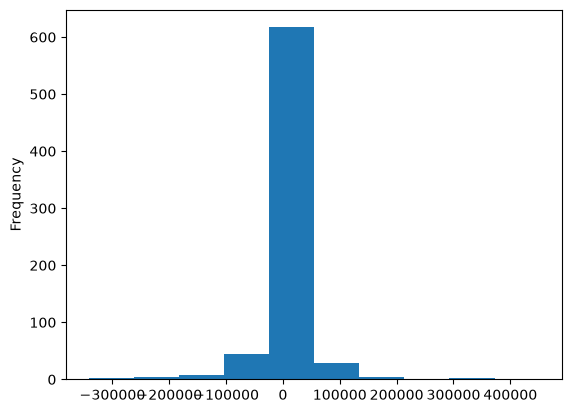

In [78]:
pd.Series(est.coef_).plot.hist()

training rmse 4425.995244011514
test rmse 4517.22207578161
training r2 0.8668253121124613
test r2 0.8595168121660235


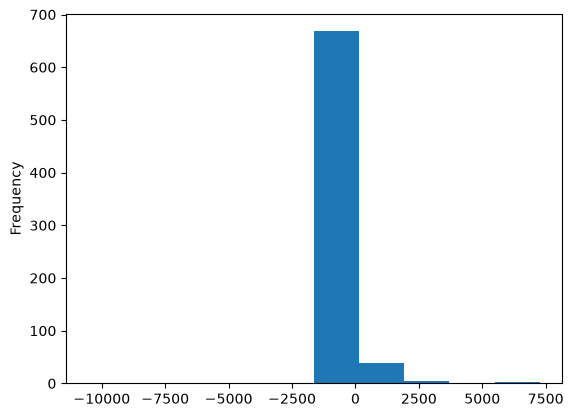

In [86]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)


pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.Lasso(max_iter=5000, alpha=10.0))
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
pd.Series(est.coef_).plot.hist();

In [87]:
est.coef_

array([ 0.00000000e+00,  0.00000000e+00,  5.95890338e+02, -6.39172029e-01,
        0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00,  3.10746210e+03,  0.00000000e+00, -8.05705691e+02,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        0.00000000e+00, -0.00000000e+00,  6.85719299e+02,  2.25992973e+03,
       -0.00000000e+00,  0.00000000e+00, -4.23193362e+02, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  9.61426968e-02,
       -0.00000000e+00,  0.00000000e+00,  7.92357631e+02,  0.00000000e+00,
        0.00000000e+00, -1.04307031e+01, -0.00000000e+00,  7.26059798e+03,
       -0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        5.14050188e+01, -

training rmse 4291.778879553606
test rmse 5017.320517449013
training r2 0.8735291679668937
test r2 0.8301984179120798


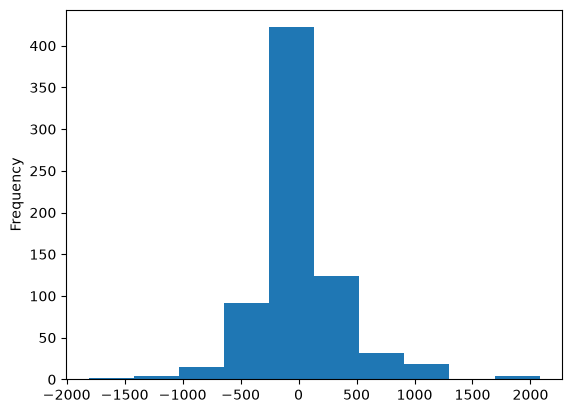

In [90]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)


pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.Ridge(max_iter=5000, alpha=10.0))
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
pd.Series(est.coef_).plot.hist();

training rmse 4905.065200279832
test rmse 4725.300566592734
training r2 0.8412656773721654
test r2 0.8334447077721843


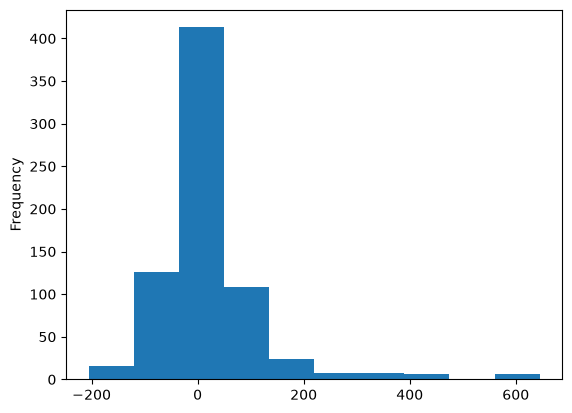

In [91]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)


pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.ElasticNet(max_iter=5000, alpha=1.0, l1_ratio=0.5))
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
pd.Series(est.coef_).plot.hist();

training rmse 5216.9788269977225
test rmse 5416.216574876232
training r2 0.8092484169293259
test r2 0.8097658447918438


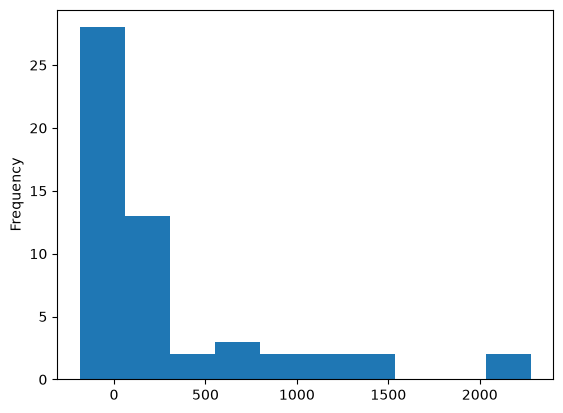

In [104]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3, random_state=654)


pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.ElasticNet(max_iter=5000, alpha=1.0, l1_ratio=0.5))
])

pipe.fit(X_train, y_train)
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print("training rmse", metrics.mean_squared_error(y_train, y_train_pred) ** 0.5)
print("test rmse", metrics.mean_squared_error(y_test, y_test_pred) ** 0.5)

print("training r2", metrics.r2_score(y_train, y_train_pred))
print("test r2", metrics.r2_score(y_test, y_test_pred))

est = pipe.steps[-1][-1]
pd.Series(est.coef_).plot.hist();

In [106]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33

pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.ElasticNet(max_iter=5000, alpha=1.0, l1_ratio=0.5))
])

scores = model_selection.cross_val_score(pipe, X, y, cv=10)
np.mean(scores), np.std(scores)

(np.float64(0.8001900473929029), np.float64(0.03773137930444319))

In [116]:
%%time 

from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics
from sklearn import pipeline

import numpy as np

target = "charges"

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True) # one hot encoding
X['high_bmi'] = X['bmi'] > 33

pipe = pipeline.Pipeline([
    ('poly', preprocessing.PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', preprocessing.StandardScaler()),
    ('est', linear_model.ElasticNet(max_iter=5000, alpha=1.0, l1_ratio=0.5))
])
param_grid = {
    'est__alpha': 2 ** np.linspace(-3, 3, 10), 
    'est__l1_ratio': np.linspace(0.1, .99, 10)
}
gsearch = model_selection.GridSearchCV(pipe, param_grid=param_grid, cv=10, scoring="r2")
gsearch.fit(X, y)

CPU times: user 10.5 s, sys: 429 μs, total: 10.5 s
Wall time: 10.5 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'est__alpha': array([0.125 ..., 8. ]), 'est__l1_ratio': array([0.1 ..., 0.99 ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the v

In [108]:
2 ** np.linspace(-3, 3, 10)

array([0.125     , 0.19842513, 0.31498026, 0.5       , 0.79370053,
       1.25992105, 2.        , 3.1748021 , 5.0396842 , 8.        ])

In [109]:
np.linspace(0.1, .99, 10)

array([0.1       , 0.19888889, 0.29777778, 0.39666667, 0.49555556,
       0.59444444, 0.69333333, 0.79222222, 0.89111111, 0.99      ])

In [112]:
gsearch.predict(X_train)

array([ 4919.70034144, 35827.00192309,  8727.75861012,  4053.24792878,
       24620.317618  ,  4722.16636767,  9371.98104132,  8608.87364001,
        5074.06760143,  3919.48631727, 11676.69434334,  8397.15099142,
       13795.27738958,  9779.22642845,  8289.00917091,  3593.24236361,
       10062.66603834, 10591.6347816 , 10287.04114835,  8295.77392755,
       11556.85264583, 10198.17256647, 12446.76350527, 30613.29847459,
       11583.47016298,  6448.45546388,  2374.72260892,  8980.90639495,
       52018.39570533,  4819.1985494 , 11642.07695086,  8940.15417992,
        8039.85460128,  4162.93573616,  6995.89271928, 10671.77968208,
        6573.04249279,  8248.51894826,  8843.27157827, 12083.43760009,
       10403.73585732,  6017.64009131,  4619.70010457,  6151.30639263,
       41903.72916794, 31958.67541385, 12156.25449702,  4711.1539853 ,
       21172.77006284,  9454.14519815, 10863.63568454,  5940.79520592,
        3725.71874593,  2737.89112509,  3463.57936212, 13930.42337735,
      

In [113]:
gsearch.best_params_

{'est__alpha': np.float64(0.125), 'est__l1_ratio': np.float64(0.99)}

In [114]:
gsearch.best_score_

np.float64(0.8360797130335245)

In [117]:
import pickle 

In [119]:
with open("model.pickle", "wb") as f:
    pickle.dump(gsearch, f)

In [122]:
!ls -l model.pickle

-rw-rw-r-- 1 aio aio 22306 Oct  1 01:15 model.pickle


In [123]:
with open("model.pickle", "rb") as f:
    model_reloaded = pickle.load(f)
    print(model_reloaded.best_params_)

{'est__alpha': np.float64(0.125), 'est__l1_ratio': np.float64(0.99)}
